# 10 — Error Analysis

**Étape 12 — Analyse erreurs (régimes, heures, saisons, drivers)**

Diagnostic fin du meilleur modèle : où et pourquoi il se trompe
(section 12 et 13 du cahier de projet). C'est cette analyse qui distingue un projet
quant sérieux d'un simple exercice de scoring.


## Setup

In [2]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src import data, features, models, backtest, metrics, plots

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (14, 4)


## Charger les prédictions du backtest (notebook 09)

In [3]:
from pathlib import Path

PROCESSED_DIR = Path("../data/processed")
FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PREDICTIONS_PATH = PROCESSED_DIR / "walk_forward_predictions.csv"
FEATURES_PATH = PROCESSED_DIR / "dataset_features.csv"


def read_time_indexed_csv(path):
    """Charge un CSV et transforme sa première colonne temporelle en index UTC."""
    frame = pd.read_csv(path)

    datetime_col = "datetime" if "datetime" in frame.columns else frame.columns[0]

    frame[datetime_col] = pd.to_datetime(
        frame[datetime_col],
        utc=True,
        errors="coerce",
    )

    frame = (
        frame.dropna(subset=[datetime_col])
        .set_index(datetime_col)
        .sort_index()
    )

    if not frame.index.is_unique:
        raise ValueError(f"Index dupliqué dans {path.name}")

    return frame


predictions = read_time_indexed_csv(PREDICTIONS_PATH)
dataset = read_time_indexed_csv(FEATURES_PATH)

# Détection automatique des colonnes
true_candidates = [
    column for column in predictions.columns
    if column.lower() in {"y_true", "actual", "reel", "réel", "price_da"}
]

model_candidates = [
    column for column in predictions.columns
    if "xgboost" in column.lower()
    and "rolling" in column.lower()
]

if not true_candidates:
    raise KeyError(
        f"Colonne réelle introuvable. Colonnes disponibles : "
        f"{predictions.columns.tolist()}"
    )

if not model_candidates:
    raise KeyError(
        f"Prédiction XGBoost rolling introuvable. Colonnes disponibles : "
        f"{predictions.columns.tolist()}"
    )

TRUE_COL = true_candidates[0]
MODEL_COL = model_candidates[0]

analysis = predictions[[TRUE_COL, MODEL_COL]].rename(
    columns={
        TRUE_COL: "y_true",
        MODEL_COL: "y_pred",
    }
)

# Variables réalisées utilisées uniquement après la prévision pour le diagnostic
diagnostic_candidates = [
    "price_da",
    "demand_actual",
    "wind_generation",
    "solar_generation",
    "nuclear_generation",
    "residual_load_actual_diagnostic",
    "low_nuclear_actual_diagnostic",
    "negative_price_flag_analysis_only",
    "spike_flag_analysis_only",
]

diagnostic_columns = [
    column for column in diagnostic_candidates
    if column in dataset.columns
]

analysis = analysis.join(
    dataset[diagnostic_columns],
    how="left",
)

analysis = analysis.dropna(subset=["y_true", "y_pred"]).copy()

# Résidu positif = sous-estimation ; résidu négatif = surestimation
analysis["residual"] = analysis["y_true"] - analysis["y_pred"]
analysis["absolute_error"] = analysis["residual"].abs()
analysis["squared_error"] = analysis["residual"] ** 2

# Calendrier dans le fuseau du marché français
local_index = analysis.index.tz_convert("Europe/Paris")

analysis["hour"] = local_index.hour
analysis["month"] = local_index.month
analysis["weekday"] = local_index.dayofweek
analysis["is_weekend"] = (local_index.dayofweek >= 5).astype(int)

print("Modèle analysé :", MODEL_COL)
print("Nombre d'heures :", len(analysis))
print("Période :", analysis.index.min(), "→", analysis.index.max())
print("Variables diagnostic disponibles :", diagnostic_columns)

display(analysis.head())
display(
    pd.DataFrame(
        [metrics.summary_metrics(analysis["y_true"], analysis["y_pred"])]
    ).round(2)
)

Modèle analysé : XGBoost — rolling
Nombre d'heures : 15113
Période : 2023-12-31 23:00:00+00:00 → 2025-09-21 22:00:00+00:00
Variables diagnostic disponibles : ['price_da', 'demand_actual', 'wind_generation', 'solar_generation', 'nuclear_generation', 'residual_load_actual_diagnostic', 'low_nuclear_actual_diagnostic', 'negative_price_flag_analysis_only', 'spike_flag_analysis_only']


,y_true,y_pred,price_da,demand_actual,wind_generation,solar_generation,nuclear_generation,residual_load_actual_diagnostic,low_nuclear_actual_diagnostic,negative_price_flag_analysis_only,spike_flag_analysis_only,residual,absolute_error,squared_error,hour,month,weekday,is_weekend
datetime,,,,,,,,,,,,,,,,,,
2023-12-31 23:00:00+00:00,0.10,37.966805,0.10,55203.0,15512.0,0.0,38986.0,39691.0,0,0,0,-37.866805,37.866805,1433.894921,0,1,0,0
2024-01-01 00:00:00+00:00,0.01,30.219320,0.01,53174.0,15324.5,0.0,37369.5,37849.5,0,0,0,-30.209320,30.209320,912.603015,1,1,0,0
2024-01-01 01:00:00+00:00,0.00,30.468004,0.00,53082.5,14884.0,0.0,37317.0,38198.5,0,0,0,-30.468004,30.468004,928.299268,2,1,0,0
2024-01-01 02:00:00+00:00,-0.01,31.160990,-0.01,50892.0,11279.5,0.0,37057.5,39612.5,0,1,0,-31.170990,31.170990,971.630618,3,1,0,0
2024-01-01 03:00:00+00:00,-0.03,31.925943,-0.03,48588.5,9040.5,0.0,36765.5,39548.0,0,1,0,-31.955943,31.955943,1021.182293,4,1,0,0


,MAE,RMSE,sMAPE,Bias,n_obs
0,18.25,23.9,52.38,-2.5,15113


In [5]:
def grouped_error_metrics(frame, group_col):
    """
    Utilise metrics_by_group puis ajoute le biais moyen.
    Résidu = réel - prédit.
    """
    clean = frame.dropna(
        subset=[group_col, "y_true", "y_pred"]
    ).copy()

    # Évite la création de catégories vides par groupby
    clean[group_col] = clean[group_col].astype(str)

    result = metrics.metrics_by_group(
        clean,
        y_true_col="y_true",
        y_pred_col="y_pred",
        group_col=group_col,
    )

    bias_table = (
        clean.groupby(group_col, observed=True)["residual"]
        .mean()
        .rename("Bias")
        .reset_index()
    )

    result = result.merge(
        bias_table,
        on=group_col,
        how="left",
    )

    return result[
        [group_col, "MAE", "RMSE", "sMAPE", "Bias", "n_obs"]
    ]

## Erreurs par heure de la journée (pointes matin/soir) (`metrics_by_group`)

,hour,MAE,RMSE,sMAPE,Bias,n_obs
0,0,18.34,23.14,40.30,2.32,631
1,1,17.05,21.78,44.31,0.20,630
2,2,16.19,20.85,44.37,-0.60,622
3,3,16.09,20.68,52.10,-3.16,630
4,4,16.49,21.07,57.36,-4.47,630
5,5,16.32,20.99,49.65,-3.25,630
6,6,17.28,22.20,40.93,-2.45,630
7,7,20.34,26.49,38.89,-0.28,630
8,8,20.89,27.85,37.92,2.07,630
9,9,17.95,24.24,45.36,-0.28,630


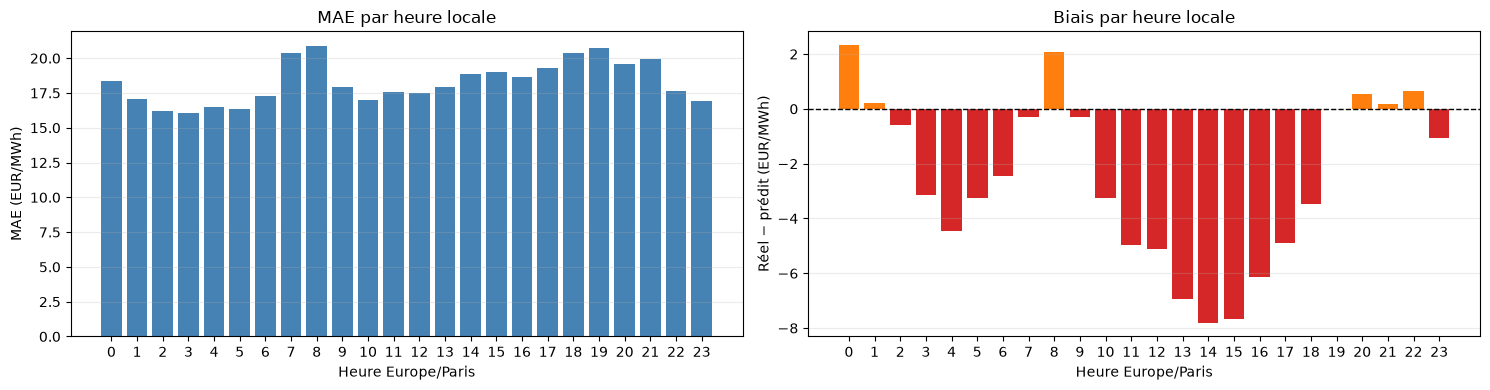

Heure avec le RMSE le plus élevé : 18


In [6]:
hour_metrics = grouped_error_metrics(analysis, "hour")

# Remettre les heures dans l'ordre numérique
hour_metrics["hour"] = hour_metrics["hour"].astype(int)
hour_metrics = hour_metrics.sort_values("hour").reset_index(drop=True)

display(hour_metrics.round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].bar(
    hour_metrics["hour"],
    hour_metrics["MAE"],
    color="steelblue",
)
axes[0].set_title("MAE par heure locale")
axes[0].set_xlabel("Heure Europe/Paris")
axes[0].set_ylabel("MAE (EUR/MWh)")
axes[0].set_xticks(range(24))
axes[0].grid(axis="y", alpha=0.25)

colors = np.where(
    hour_metrics["Bias"] >= 0,
    "tab:orange",
    "tab:red",
)

axes[1].bar(
    hour_metrics["hour"],
    hour_metrics["Bias"],
    color=colors,
)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Biais par heure locale")
axes[1].set_xlabel("Heure Europe/Paris")
axes[1].set_ylabel("Réel − prédit (EUR/MWh)")
axes[1].set_xticks(range(24))
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

print(
    "Heure avec le RMSE le plus élevé :",
    int(hour_metrics.loc[hour_metrics["RMSE"].idxmax(), "hour"]),
)

## Erreurs par saison

,season,MAE,RMSE,sMAPE,Bias,n_obs
0,Hiver,18.74,25.80,26.57,1.60,3600
1,Printemps,17.75,23.30,65.01,-6.91,4408
2,Été,18.16,23.07,60.23,-1.86,4416
3,Automne,18.57,23.57,53.35,-1.78,2689


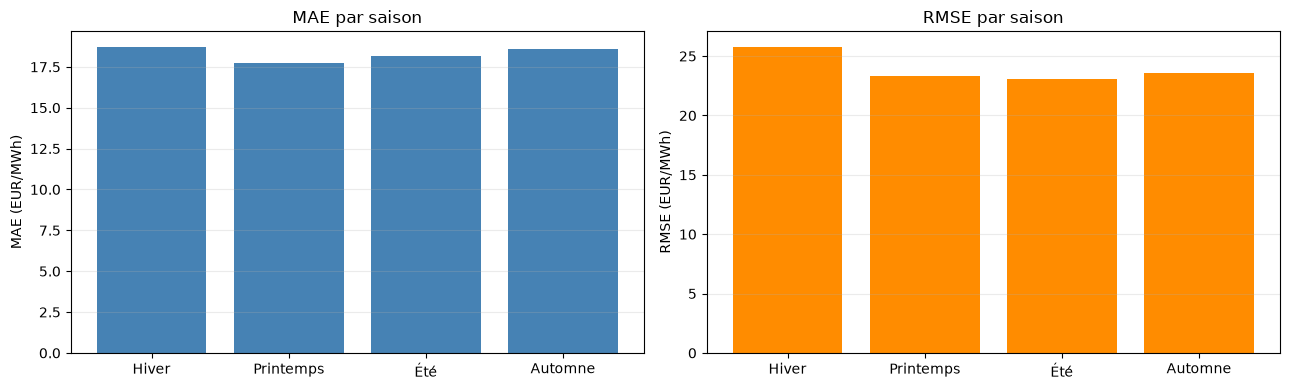

In [7]:
def season_from_month(month):
    if month in [12, 1, 2]:
        return "Hiver"
    if month in [3, 4, 5]:
        return "Printemps"
    if month in [6, 7, 8]:
        return "Été"
    return "Automne"


analysis["season"] = analysis["month"].map(season_from_month)

season_metrics = grouped_error_metrics(analysis, "season")

season_order = ["Hiver", "Printemps", "Été", "Automne"]

season_metrics["season_order"] = season_metrics["season"].map(
    {season: position for position, season in enumerate(season_order)}
)

season_metrics = (
    season_metrics
    .sort_values("season_order")
    .drop(columns="season_order")
    .reset_index(drop=True)
)

display(season_metrics.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(
    season_metrics["season"],
    season_metrics["MAE"],
    color="steelblue",
)
axes[0].set_title("MAE par saison")
axes[0].set_ylabel("MAE (EUR/MWh)")
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(
    season_metrics["season"],
    season_metrics["RMSE"],
    color="darkorange",
)
axes[1].set_title("RMSE par saison")
axes[1].set_ylabel("RMSE (EUR/MWh)")
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

## Erreurs par régime de prix (normal / négatif / spike)

Seuil de spike Q95 appris avant le backtest : 472.38 EUR/MWh


,nombre_heures
price_regime,
Normal,14275
Prix négatif,837
Spike,1


,price_regime,MAE,RMSE,sMAPE,Bias,n_obs
0,Normal,18.19,23.69,45.60,-1.79,14275
1,Prix négatif,18.89,25.17,167.93,-14.85,837
2,Spike,300.14,300.14,92.86,300.14,1


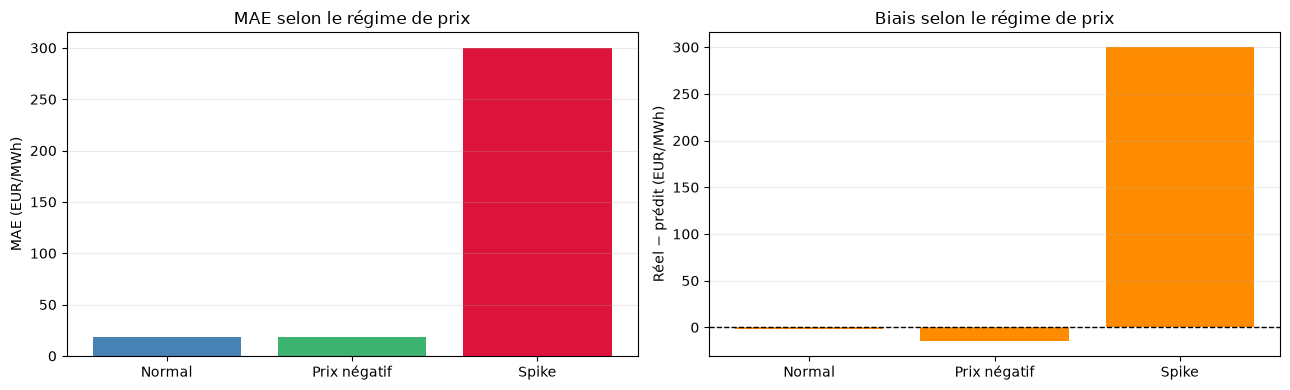

In [8]:
BACKTEST_START = analysis.index.min()

train_before_backtest = dataset.loc[
    dataset.index < BACKTEST_START
].copy()

if "price_da" not in train_before_backtest.columns:
    raise KeyError("La colonne price_da manque dans dataset_features.csv")

SPIKE_THRESHOLD = float(
    train_before_backtest["price_da"].quantile(0.95)
)

analysis["price_regime"] = np.select(
    [
        analysis["y_true"] < 0,
        analysis["y_true"] >= SPIKE_THRESHOLD,
    ],
    [
        "Prix négatif",
        "Spike",
    ],
    default="Normal",
)

regime_metrics = grouped_error_metrics(analysis, "price_regime")

regime_order = {
    "Normal": 0,
    "Prix négatif": 1,
    "Spike": 2,
}

regime_metrics["regime_order"] = regime_metrics["price_regime"].map(
    regime_order
)

regime_metrics = (
    regime_metrics
    .sort_values("regime_order")
    .drop(columns="regime_order")
    .reset_index(drop=True)
)

print(
    f"Seuil de spike Q95 appris avant le backtest : "
    f"{SPIKE_THRESHOLD:.2f} EUR/MWh"
)

display(
    analysis["price_regime"]
    .value_counts()
    .rename("nombre_heures")
    .to_frame()
)

display(regime_metrics.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(
    regime_metrics["price_regime"],
    regime_metrics["MAE"],
    color=["steelblue", "mediumseagreen", "crimson"][
        :len(regime_metrics)
    ],
)
axes[0].set_title("MAE selon le régime de prix")
axes[0].set_ylabel("MAE (EUR/MWh)")
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(
    regime_metrics["price_regime"],
    regime_metrics["Bias"],
    color="darkorange",
)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Biais selon le régime de prix")
axes[1].set_ylabel("Réel − prédit (EUR/MWh)")
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

## Erreurs par niveau de residual load

Colonne utilisée : residual_load_actual_diagnostic
Seuils appris avant le backtest : Q25=35131.88, Q75=48774.12


,residual_load_level,MAE,RMSE,sMAPE,Bias,n_obs
0,Faible,18.45,23.59,93.38,-10.91,4937
1,Intermédiaire,19.05,24.63,40.44,-1.20,6894
2,Élevée,16.27,22.79,15.80,7.45,3282


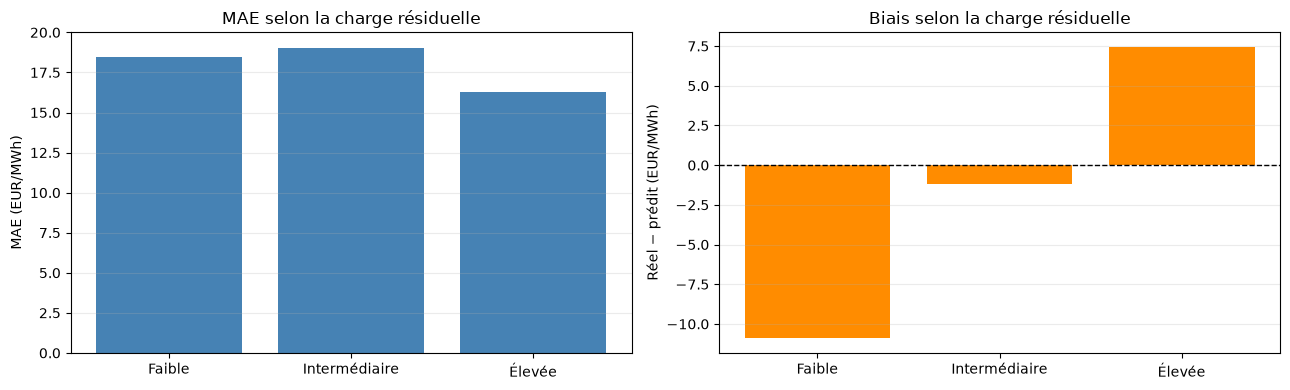

In [9]:
residual_load_candidates = [
    "residual_load_actual_diagnostic",
    "residual_load",
]

RESIDUAL_LOAD_COL = next(
    (
        column for column in residual_load_candidates
        if column in dataset.columns
    ),
    None,
)

# Reconstruction de secours si la colonne n'existe pas
if RESIDUAL_LOAD_COL is None:
    required = [
        "demand_actual",
        "wind_generation",
        "solar_generation",
    ]

    missing = [
        column for column in required
        if column not in dataset.columns
    ]

    if missing:
        raise KeyError(
            f"Residual load impossible à construire. Colonnes manquantes : "
            f"{missing}"
        )

    dataset["residual_load_reconstructed"] = (
        dataset["demand_actual"]
        - dataset["wind_generation"]
        - dataset["solar_generation"]
    )

    RESIDUAL_LOAD_COL = "residual_load_reconstructed"

# Ajout si elle n'avait pas déjà été jointe
if RESIDUAL_LOAD_COL not in analysis.columns:
    analysis = analysis.join(
        dataset[[RESIDUAL_LOAD_COL]],
        how="left",
    )

train_residual = dataset.loc[
    dataset.index < BACKTEST_START,
    RESIDUAL_LOAD_COL,
].dropna()

residual_q25 = train_residual.quantile(0.25)
residual_q75 = train_residual.quantile(0.75)

analysis["residual_load_level"] = pd.cut(
    analysis[RESIDUAL_LOAD_COL],
    bins=[-np.inf, residual_q25, residual_q75, np.inf],
    labels=["Faible", "Intermédiaire", "Élevée"],
    include_lowest=True,
)

residual_load_metrics = grouped_error_metrics(
    analysis,
    "residual_load_level",
)

residual_order = {
    "Faible": 0,
    "Intermédiaire": 1,
    "Élevée": 2,
}

residual_load_metrics["level_order"] = (
    residual_load_metrics["residual_load_level"].map(residual_order)
)

residual_load_metrics = (
    residual_load_metrics
    .sort_values("level_order")
    .drop(columns="level_order")
    .reset_index(drop=True)
)

print("Colonne utilisée :", RESIDUAL_LOAD_COL)
print(
    f"Seuils appris avant le backtest : "
    f"Q25={residual_q25:.2f}, Q75={residual_q75:.2f}"
)

display(residual_load_metrics.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(
    residual_load_metrics["residual_load_level"],
    residual_load_metrics["MAE"],
    color="steelblue",
)
axes[0].set_title("MAE selon la charge résiduelle")
axes[0].set_ylabel("MAE (EUR/MWh)")
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(
    residual_load_metrics["residual_load_level"],
    residual_load_metrics["Bias"],
    color="darkorange",
)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Biais selon la charge résiduelle")
axes[1].set_ylabel("Réel − prédit (EUR/MWh)")
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

## Erreurs selon la disponibilité nucléaire

Seuil nucléaire faible : 28.62 GW
Seuil nucléaire élevé : 39.51 GW


,nuclear_level,MAE,RMSE,sMAPE,Bias,n_obs
0,Faible,17.15,24.32,149.04,-12.41,447
1,Normale,19.66,24.77,85.42,-9.27,5462
2,Élevée,17.47,23.35,28.08,2.01,9204


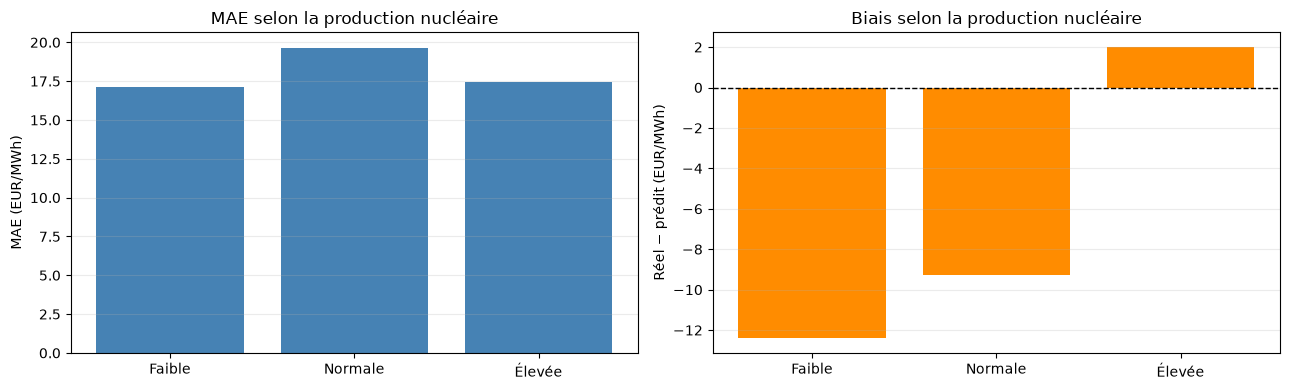

In [10]:
if "nuclear_generation" not in dataset.columns:
    raise KeyError(
        "La colonne nuclear_generation manque dans dataset_features.csv"
    )

if "nuclear_generation" not in analysis.columns:
    analysis = analysis.join(
        dataset[["nuclear_generation"]],
        how="left",
    )

train_nuclear = dataset.loc[
    dataset.index < BACKTEST_START,
    "nuclear_generation",
].dropna()

nuclear_q25 = train_nuclear.quantile(0.25)
nuclear_q75 = train_nuclear.quantile(0.75)

analysis["nuclear_level"] = pd.cut(
    analysis["nuclear_generation"],
    bins=[-np.inf, nuclear_q25, nuclear_q75, np.inf],
    labels=["Faible", "Normale", "Élevée"],
    include_lowest=True,
)

nuclear_metrics = grouped_error_metrics(
    analysis,
    "nuclear_level",
)

nuclear_order = {
    "Faible": 0,
    "Normale": 1,
    "Élevée": 2,
}

nuclear_metrics["level_order"] = (
    nuclear_metrics["nuclear_level"].map(nuclear_order)
)

nuclear_metrics = (
    nuclear_metrics
    .sort_values("level_order")
    .drop(columns="level_order")
    .reset_index(drop=True)
)

unit_factor = (
    1000 if train_nuclear.median() > 1000 else 1
)

unit_label = (
    "GW" if unit_factor == 1000 else "unité source"
)

print(
    "Seuil nucléaire faible :",
    round(nuclear_q25 / unit_factor, 2),
    unit_label,
)

print(
    "Seuil nucléaire élevé :",
    round(nuclear_q75 / unit_factor, 2),
    unit_label,
)

display(nuclear_metrics.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(
    nuclear_metrics["nuclear_level"],
    nuclear_metrics["MAE"],
    color="steelblue",
)
axes[0].set_title("MAE selon la production nucléaire")
axes[0].set_ylabel("MAE (EUR/MWh)")
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(
    nuclear_metrics["nuclear_level"],
    nuclear_metrics["Bias"],
    color="darkorange",
)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Biais selon la production nucléaire")
axes[1].set_ylabel("Réel − prédit (EUR/MWh)")
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

## Synthèse : forces et limites du modèle, pistes d'amélioration

In [11]:
worst_hour = hour_metrics.loc[hour_metrics["RMSE"].idxmax()]
best_hour = hour_metrics.loc[hour_metrics["RMSE"].idxmin()]

worst_season = season_metrics.loc[season_metrics["RMSE"].idxmax()]
worst_regime = regime_metrics.loc[regime_metrics["RMSE"].idxmax()]

worst_residual = residual_load_metrics.loc[
    residual_load_metrics["RMSE"].idxmax()
]

worst_nuclear = nuclear_metrics.loc[
    nuclear_metrics["RMSE"].idxmax()
]

overall = metrics.summary_metrics(
    analysis["y_true"],
    analysis["y_pred"],
)

print("SYNTHÈSE DU DIAGNOSTIC")
print("=" * 70)

print(
    f"Performance globale : MAE={overall['MAE']:.2f}, "
    f"RMSE={overall['RMSE']:.2f}, "
    f"Biais={overall['Bias']:.2f} EUR/MWh."
)

print(
    f"Heure la plus difficile : {int(worst_hour['hour']):02d}h "
    f"(RMSE={worst_hour['RMSE']:.2f})."
)

print(
    f"Heure la plus facile : {int(best_hour['hour']):02d}h "
    f"(RMSE={best_hour['RMSE']:.2f})."
)

print(
    f"Saison la plus difficile : {worst_season['season']} "
    f"(RMSE={worst_season['RMSE']:.2f})."
)

print(
    f"Régime de prix le plus difficile : "
    f"{worst_regime['price_regime']} "
    f"(RMSE={worst_regime['RMSE']:.2f})."
)

print(
    f"Niveau de charge résiduelle le plus difficile : "
    f"{worst_residual['residual_load_level']} "
    f"(RMSE={worst_residual['RMSE']:.2f})."
)

print(
    f"Niveau nucléaire le plus difficile : "
    f"{worst_nuclear['nuclear_level']} "
    f"(RMSE={worst_nuclear['RMSE']:.2f})."
)

print("\nFORCES")
print("• Bonne capture de la dynamique quotidienne générale.")
print("• Amélioration nette par rapport à la baseline J−1.")
print("• Robustesse confirmée sur 21 fenêtres walk-forward.")
print("• Fenêtre rolling adaptée aux changements de régime.")

print("\nLIMITES")
print("• Les pointes et les prix négatifs restent difficiles.")
print("• Les prévisions ont tendance à lisser les valeurs extrêmes.")
print("• Les résidus présentent encore une structure temporelle.")
print("• Les fondamentaux réalisés ne sont pas disponibles en production.")

print("\nPISTES D'AMÉLIORATION")
print("• Ajouter des prévisions J−1 fiables de demande, vent et solaire.")
print("• Ajouter une prévision de disponibilité nucléaire.")
print("• Tester un objectif robuste ou quantile.")
print("• Mettre en place une calibration dynamique du biais.")
print("• Détecter séparément les régimes extrêmes.")

SYNTHÈSE DU DIAGNOSTIC
Performance globale : MAE=18.25, RMSE=23.90, Biais=-2.50 EUR/MWh.
Heure la plus difficile : 18h (RMSE=27.96).
Heure la plus facile : 03h (RMSE=20.68).
Saison la plus difficile : Hiver (RMSE=25.80).
Régime de prix le plus difficile : Spike (RMSE=300.14).
Niveau de charge résiduelle le plus difficile : Intermédiaire (RMSE=24.63).
Niveau nucléaire le plus difficile : Normale (RMSE=24.77).

FORCES
• Bonne capture de la dynamique quotidienne générale.
• Amélioration nette par rapport à la baseline J−1.
• Robustesse confirmée sur 21 fenêtres walk-forward.
• Fenêtre rolling adaptée aux changements de régime.

LIMITES
• Les pointes et les prix négatifs restent difficiles.
• Les prévisions ont tendance à lisser les valeurs extrêmes.
• Les résidus présentent encore une structure temporelle.
• Les fondamentaux réalisés ne sont pas disponibles en production.

PISTES D'AMÉLIORATION
• Ajouter des prévisions J−1 fiables de demande, vent et solaire.
• Ajouter une prévision de di

## Export des figures clés vers `reports/figures/` pour le rapport final

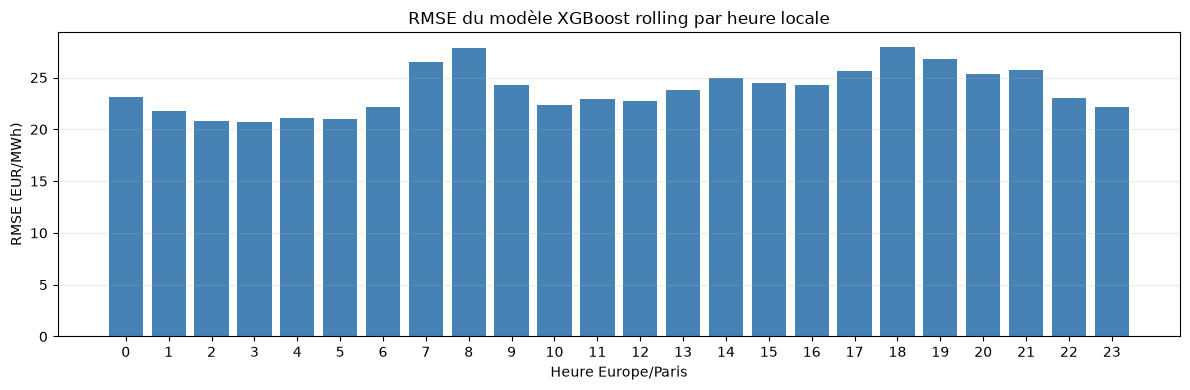

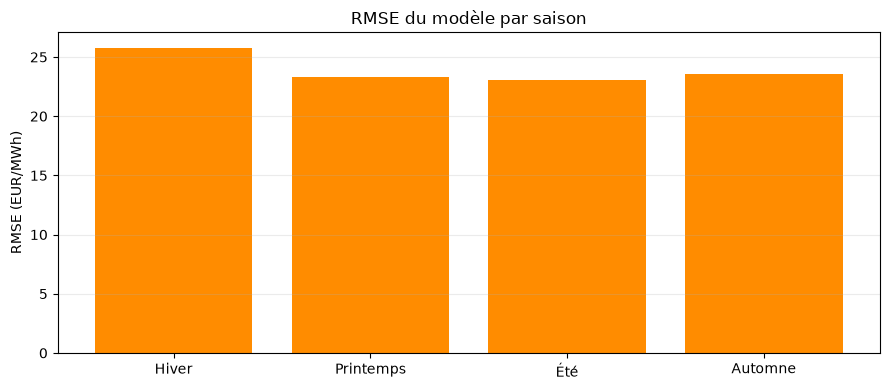

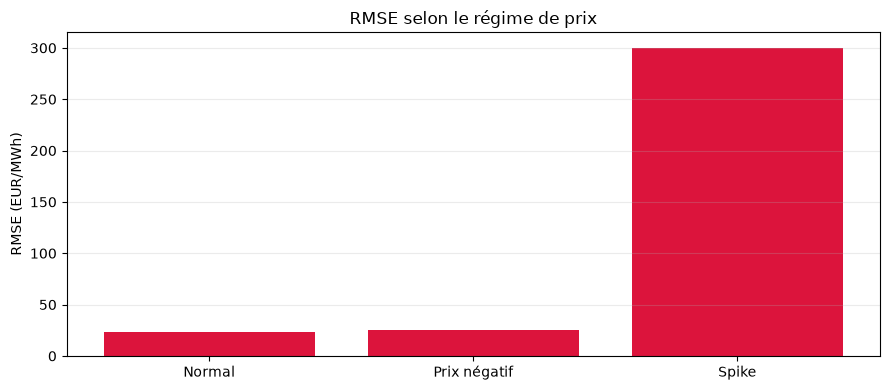

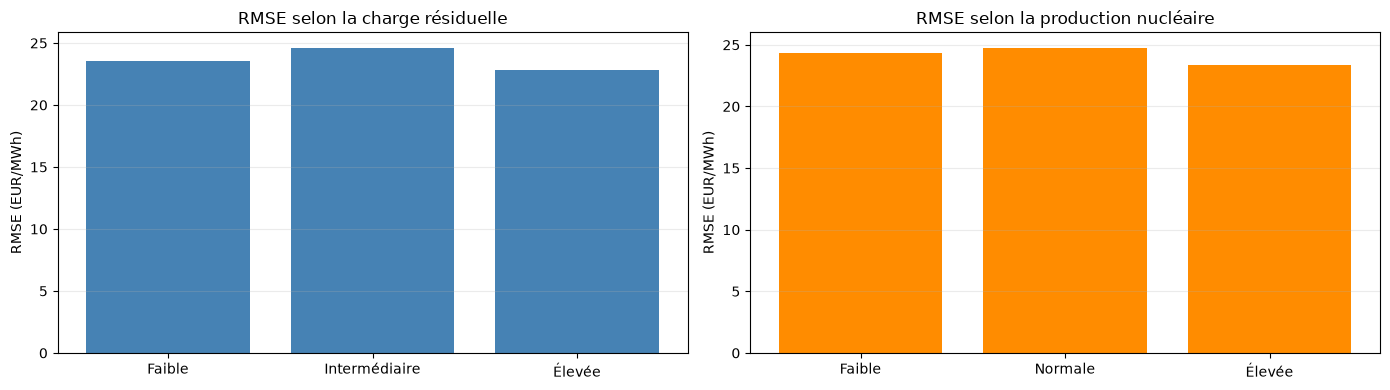

Figures enregistrées dans : /Users/evitafaj/Desktop/Portofolio/electricity-price-forecasting/reports/figures
Tableaux enregistrés dans : /Users/evitafaj/Desktop/Portofolio/electricity-price-forecasting/data/processed


In [12]:
# Figure 1 — erreurs horaires
fig, ax = plt.subplots(figsize=(12, 4))

ax.bar(
    hour_metrics["hour"],
    hour_metrics["RMSE"],
    color="steelblue",
)

ax.set_title("RMSE du modèle XGBoost rolling par heure locale")
ax.set_xlabel("Heure Europe/Paris")
ax.set_ylabel("RMSE (EUR/MWh)")
ax.set_xticks(range(24))
ax.grid(axis="y", alpha=0.25)

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "error_rmse_by_hour.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()


# Figure 2 — erreurs saisonnières
fig, ax = plt.subplots(figsize=(9, 4))

ax.bar(
    season_metrics["season"],
    season_metrics["RMSE"],
    color="darkorange",
)

ax.set_title("RMSE du modèle par saison")
ax.set_ylabel("RMSE (EUR/MWh)")
ax.grid(axis="y", alpha=0.25)

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "error_rmse_by_season.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()


# Figure 3 — régimes de prix
fig, ax = plt.subplots(figsize=(9, 4))

ax.bar(
    regime_metrics["price_regime"],
    regime_metrics["RMSE"],
    color="crimson",
)

ax.set_title("RMSE selon le régime de prix")
ax.set_ylabel("RMSE (EUR/MWh)")
ax.grid(axis="y", alpha=0.25)

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "error_rmse_by_price_regime.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()


# Figure 4 — drivers système
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(
    residual_load_metrics["residual_load_level"],
    residual_load_metrics["RMSE"],
    color="steelblue",
)
axes[0].set_title("RMSE selon la charge résiduelle")
axes[0].set_ylabel("RMSE (EUR/MWh)")
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(
    nuclear_metrics["nuclear_level"],
    nuclear_metrics["RMSE"],
    color="darkorange",
)
axes[1].set_title("RMSE selon la production nucléaire")
axes[1].set_ylabel("RMSE (EUR/MWh)")
axes[1].grid(axis="y", alpha=0.25)

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "error_system_drivers.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()


# Export des tableaux
hour_metrics.to_csv(
    PROCESSED_DIR / "error_metrics_by_hour.csv",
    index=False,
)

season_metrics.to_csv(
    PROCESSED_DIR / "error_metrics_by_season.csv",
    index=False,
)

regime_metrics.to_csv(
    PROCESSED_DIR / "error_metrics_by_price_regime.csv",
    index=False,
)

residual_load_metrics.to_csv(
    PROCESSED_DIR / "error_metrics_by_residual_load.csv",
    index=False,
)

nuclear_metrics.to_csv(
    PROCESSED_DIR / "error_metrics_by_nuclear_level.csv",
    index=False,
)

print("Figures enregistrées dans :", FIGURES_DIR.resolve())
print("Tableaux enregistrés dans :", PROCESSED_DIR.resolve())